# Analyse Exploratoire du Dataset Orange
### TP: Identification des informations utiles sur le fruit d'orange
---
**Objectif :** Explorer et comprendre les caractéristiques physico-chimiques des oranges afin d'identifier les facteurs déterminant leur qualité.


## 1- Importation des Bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2- Chargement et Apercu du Dataset

In [2]:
dataOrange=pd.read_csv("orange.csv")

In [4]:
dataOrange.head(8)

,Size (cm),Weight (g),Brix (Sweetness),pH (Acidity),Softness (1-5),HarvestTime (days),Ripeness (1-5),Color,Variety,Blemishes (Y/N),Quality (1-5)
0,7.5,180,12.0,3.2,2.0,10,4.0,Orange,Valencia,N,4.0
1,8.2,220,10.5,3.4,3.0,14,4.5,Deep Orange,Navel,N,4.5
2,6.8,150,14.0,3.0,1.0,7,5.0,Light Orange,Cara Cara,N,5.0
3,9.0,250,8.5,3.8,4.0,21,3.5,Orange-Red,Blood Orange,N,3.5
4,8.5,210,11.5,3.3,2.5,12,5.0,Orange,Hamlin,Y (Minor),4.5
5,6.7,126,9.1,3.0,2.0,25,2.0,Orange,Navel,N,1.0
6,7.2,160,9.0,3.5,3.5,9,4.0,Yellow-Orange,Tangelo (Hybrid),N,4.0
7,6.5,130,13.5,2.8,1.5,5,4.5,Light Orange,Murcott (Hybrid),N,4.5


In [5]:
# taille du dataset
print("Nombre de lignes : ", dataOrange.shape[0])
print("Nombre de colonnes : ", dataOrange.shape[1])

Nombre de lignes :  241
Nombre de colonnes :  11


In [6]:
# type des données
print("Types de données : \n", dataOrange.dtypes)

Types de données : 
 Size (cm)             float64
Weight (g)              int64
Brix (Sweetness)      float64
pH (Acidity)          float64
Softness (1-5)        float64
HarvestTime (days)      int64
Ripeness (1-5)        float64
Color                  object
Variety                object
Blemishes (Y/N)        object
Quality (1-5)         float64
dtype: object


In [7]:
# valeurs manquantes
print("Valeurs manquantes : \n", dataOrange.isna().sum())

Valeurs manquantes : 
 Size (cm)             0
Weight (g)            0
Brix (Sweetness)      0
pH (Acidity)          0
Softness (1-5)        0
HarvestTime (days)    0
Ripeness (1-5)        0
Color                 0
Variety               0
Blemishes (Y/N)       0
Quality (1-5)         0
dtype: int64


In [8]:
# detection des doublons
print("Nombre de doublons : ", dataOrange.duplicated().sum())

Nombre de doublons :  0


In [9]:
# renommages de certaines colonnes
dataOrange = dataOrange.rename(columns={
    'Size (cm)': 'Size(cm)',
    'Weight (g)': 'Weight(g)',
    'Brix (Sweetness)': 'Brix(Sweetness)',
    'pH (Acidity)': 'pH(Acidity)',
    'Softness (1-5)': 'Softness(1-5)',
    'HarvestTime (days)': 'HarvestTime(days)',
    'Ripeness (1-5)': 'Ripeness(1-5)',
    'Blemishes (Y/N)': 'Blemishes(Y/N)',
    'Quality (1-5)': 'Quality(1-5)'
})

In [10]:
# verification des changements
print("Noms des colonnes après renommage : \n", dataOrange.columns)

Noms des colonnes après renommage : 
 Index(['Size(cm)', 'Weight(g)', 'Brix(Sweetness)', 'pH(Acidity)',
       'Softness(1-5)', 'HarvestTime(days)', 'Ripeness(1-5)', 'Color',
       'Variety', 'Blemishes(Y/N)', 'Quality(1-5)'],
      dtype='object')


In [11]:
dataOrange.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241 entries, 0 to 240
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Size(cm)           241 non-null    float64
 1   Weight(g)          241 non-null    int64  
 2   Brix(Sweetness)    241 non-null    float64
 3   pH(Acidity)        241 non-null    float64
 4   Softness(1-5)      241 non-null    float64
 5   HarvestTime(days)  241 non-null    int64  
 6   Ripeness(1-5)      241 non-null    float64
 7   Color              241 non-null    object 
 8   Variety            241 non-null    object 
 9   Blemishes(Y/N)     241 non-null    object 
 10  Quality(1-5)       241 non-null    float64
dtypes: float64(6), int64(2), object(3)
memory usage: 20.8+ KB


## 3- Statistiques Descriptives

In [12]:
# Variables numériques
print("Statistiques des variables numériques :")
dataOrange.describe().round(4)

Statistiques des variables numériques :


,Size(cm),Weight(g),Brix(Sweetness),pH(Acidity),Softness(1-5),HarvestTime(days),Ripeness(1-5),Quality(1-5)
count,241.0000,241.0000,241.0000,241.0000,241.0000,241.0000,241.0000,241.0000
mean,7.8448,205.1286,10.9079,3.4739,3.0726,15.3444,3.5996,3.8174
std,1.0860,56.4610,2.7604,0.4210,1.3236,5.3239,1.2052,1.0144
min,6.0000,100.0000,5.5000,2.8000,1.0000,4.0000,1.0000,1.0000
25%,6.9000,155.0000,8.5000,3.2000,2.0000,11.0000,3.0000,3.0000
50%,7.8000,205.0000,11.0000,3.4000,3.0000,15.0000,4.0000,4.0000
75%,8.7000,252.0000,13.4000,3.8000,4.0000,20.0000,4.5000,4.5000
max,10.0000,300.0000,16.0000,4.4000,5.0000,25.0000,5.0000,5.0000


## Interpretation
 Sur les 241 oranges analysées, les résultats sont globalement encourageants. La qualité se révèle assez homogène, avec une note moyenne de 3,8 sur 5. la plupart des fruits dépassent d'ailleurs la barre des 4.Côté profil gustatif, on est sur des oranges bien sucrées, avec un indice Brix autour de 10,9, et une acidité tout à fait classique pour la variété (pH de 3,47 en moyenne).
Les gabarits varient pas mal d'un fruit à l'autre entre 100 g et 300 g  ce qui traduit une certaine diversité physique dans l'échantillon. Enfin, la maturité est au rendez-vous : les fruits sont bien mûrs en moyenne (3,6/5), récoltés environ 15 jours après le pic de maturité.

In [13]:
# variables categorielles
print("nombre d'orange par couleur : \n", dataOrange['Color'].value_counts())
print("\nnombre d'orange par variety : \n", dataOrange['Variety'].value_counts())

nombre d'orange par couleur : 
 Color
Deep Orange      75
Light Orange     64
Orange-Red       55
Orange           38
Yellow-Orange     9
Name: count, dtype: int64

nombre d'orange par variety : 
 Variety
Cara Cara                21
Star Ruby                18
Temple                   18
Navel                    16
Moro (Blood)             16
Washington Navel         14
Clementine               14
Tangerine                14
Ortanique (Hybrid)       13
Satsuma Mandarin         13
Minneola (Hybrid)        12
Ambiance                 11
Valencia                 11
Jaffa                    11
Honey Tangerine           7
California Valencia       7
Midsweet (Hybrid)         5
Hamlin                    5
Clementine (Seedless)     4
Murcott (Hybrid)          3
Navel (Late Season)       3
Blood Orange              2
Navel (Early Season)      2
Tangelo (Hybrid)          1
Name: count, dtype: int64


## 4- Distribution des Variables Numeriques : Analyse univariees des variables numeriques

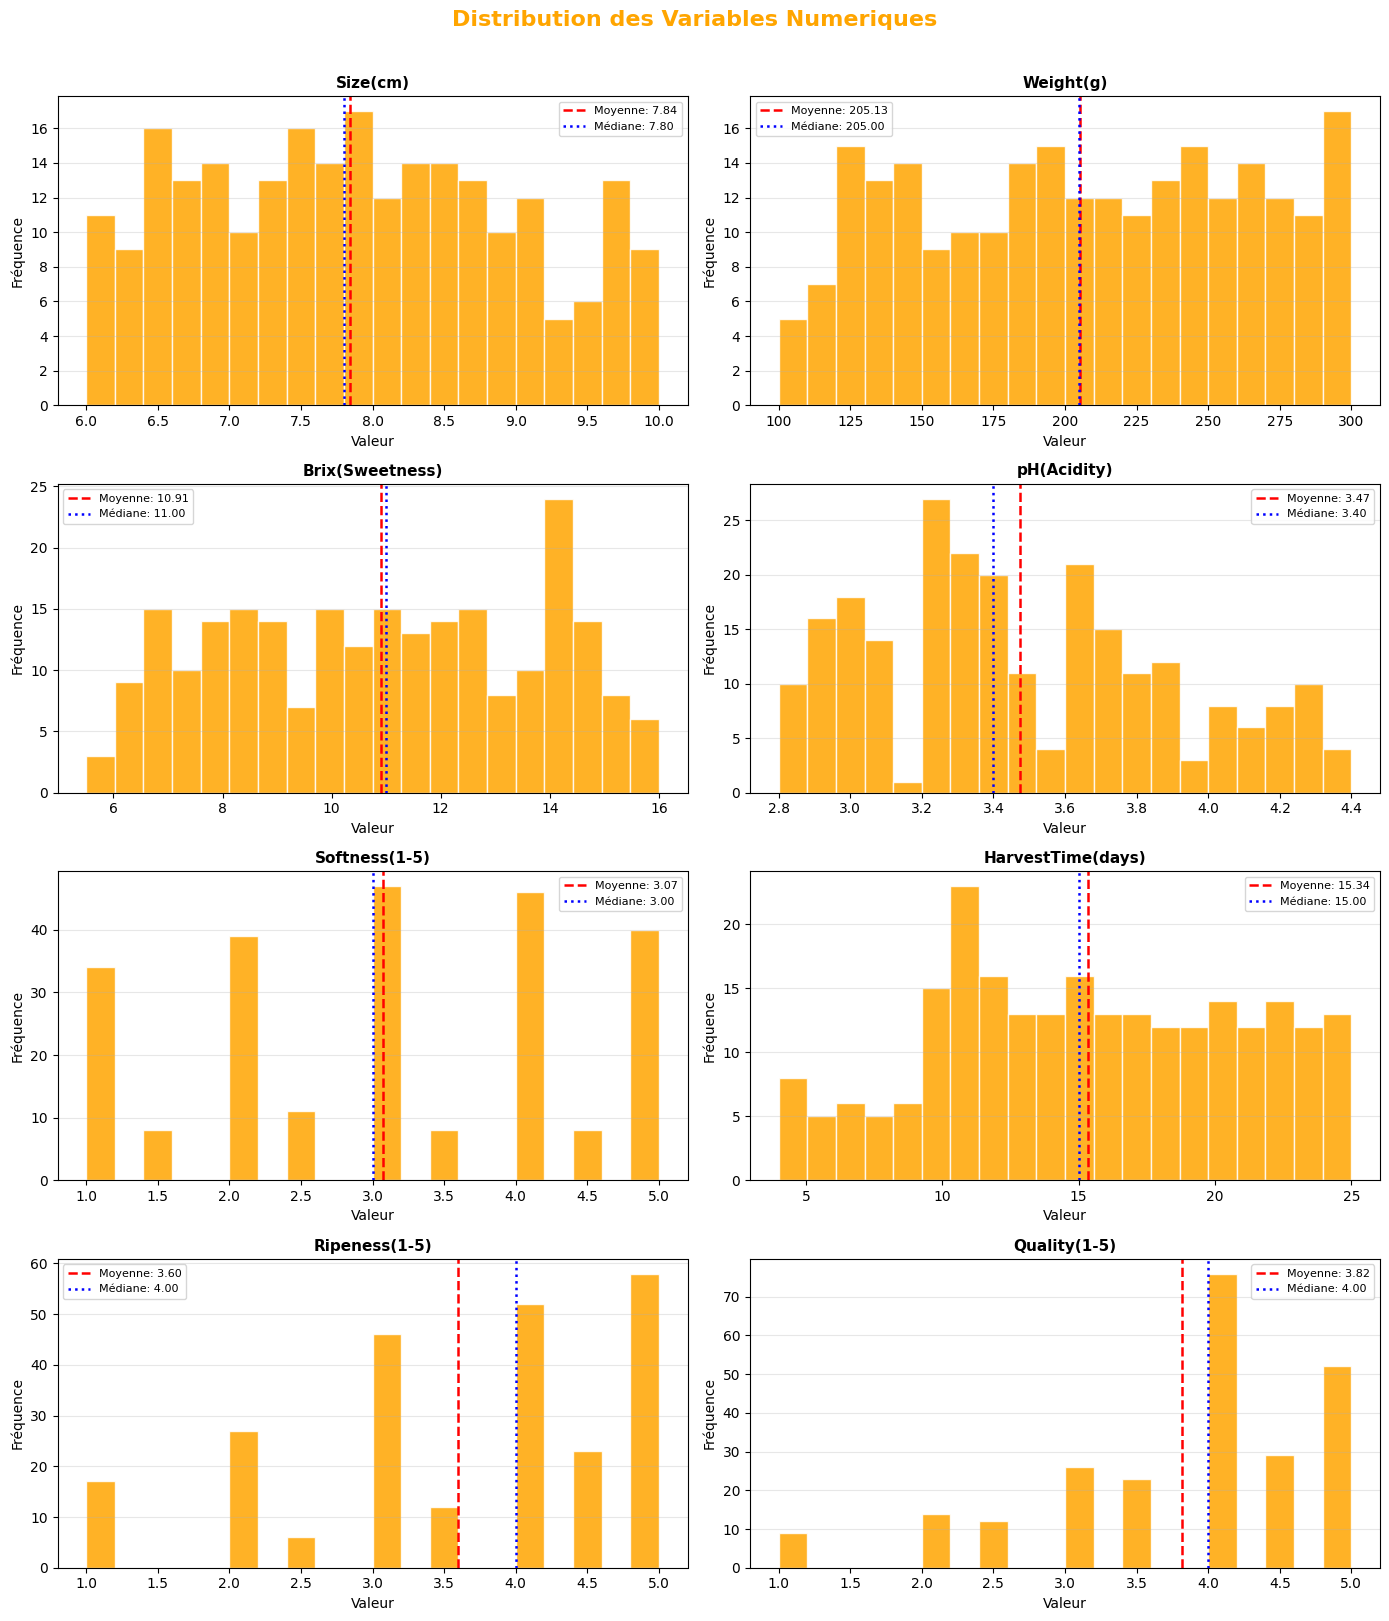

In [14]:
num_cols = ['Size(cm)', 'Weight(g)', 'Brix(Sweetness)', 'pH(Acidity)',
            'Softness(1-5)', 'HarvestTime(days)', 'Ripeness(1-5)', 'Quality(1-5)']

fig, axes = plt.subplots(4, 2, figsize=(14, 16))
fig.suptitle('Distribution des Variables Numeriques', fontsize=16, fontweight='bold', color='orange', y=1.01)

for i, col in enumerate(num_cols):
    ax = axes[i // 2][i % 2]
    data = dataOrange[col].dropna()
    ax.hist(data, bins=20, color='orange', edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1.8, label=f'Moyenne: {data.mean():.2f}')
    ax.axvline(data.median(), color='blue', linestyle=':', linewidth=1.8, label=f'Médiane: {data.median():.2f}')
    ax.set_title(col, fontweight='bold', fontsize=11)
    ax.set_xlabel('Valeur')
    ax.set_ylabel('Fréquence')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


# Interprétation de la Distribution des Variables Numeriques

**Qualité (Quality 1-5)**
La qualité est clairement orientée vers le haut : la grande majorité des oranges obtiennent une note de 4 ou 5, avec une moyenne de 3,82. Les fruits de mauvaise qualité (note 1 ou 2) sont vraiment l'exception. C'est le signe d'un lot globalement sain et bien sélectionné.

**Maturité (Ripeness 1-5)**
La maturité suit la même tendance : les notes 4 et 5 dominent largement, même si on note une présence non négligeable de fruits à 1 et 2. Cela suggère que la récolte mélange des fruits bien mûrs et quelques fruits cueillis trop tôt ou trop tard.

**Douceur (Brix/Sweetness)**
C'est l'observation la plus intéressante du graphique : la distribution n'est pas régulière, elle présente **deux bosses distinctes**, l'une autour de 8 et l'autre autour de 14. Cela ne ressemble pas à un hasard — on a probablement affaire à deux groupes de fruits différents, que ce soit deux variétés d'oranges, deux origines géographiques, ou deux stades de maturité bien distincts. C'est une piste qui mérite d'être creusée.

**Acidité (pH)**
Le pH est très concentré entre 3,2 et 3,6, avec une moyenne de 3,47. Les oranges de cet échantillon sont donc remarquablement homogènes en termes d'acidité. Tout fruit qui sort de cette fourchette étroite mérite attention : il pourrait s'agir d'une anomalie de mesure, d'une variété atypique, ou d'un fruit en mauvais état.

**Texture (Softness 1-5)**
La texture est très particulière : les valeurs se concentrent presque exclusivement sur 1, 3 et 5, avec très peu de valeurs intermédiaires. Cette distribution discontinue suggère que la texture a été évaluée de façon subjective et catégorielle plutôt que mesurée précisément. En clair, les évaluateurs ont tranché : une orange est soit ferme, soit moyenne, soit molle.

**Taille et Poids (Size/Weight)**
Les deux distributions sont relativement étalées, couvrant une large gamme de tailles (6 à 10 cm) et de poids (100 à 300 g). Rien d'anormal ici — c'est simplement le reflet de la variabilité naturelle des fruits. On peut raisonnablement supposer que taille et poids sont liés, mais cela reste à confirmer par une analyse de corrélation.

**Temps de récolte (HarvestTime)**
Contrairement à ce qu'on pourrait croire, la distribution n'est pas parfaitement uniforme. On observe un pic notable autour de 12-13 jours, puis les valeurs se répartissent plus librement jusqu'à 25 jours. L'échantillon couvre bien différents stades post-récolte, mais avec une légère surreprésentation des fruits récoltés à mi-parcours.

Donc cet échantillon décrit globalement des oranges de bonne qualité et bien mûres, avec une acidité très stable. Le point le plus intrigant reste la douceur, dont la distribution en deux groupes distincts soulève une vraie question sur la composition du lot et mériterait une investigation plus poussée.

## 5- Analyse des Variables Categorielles : Analyse univariee

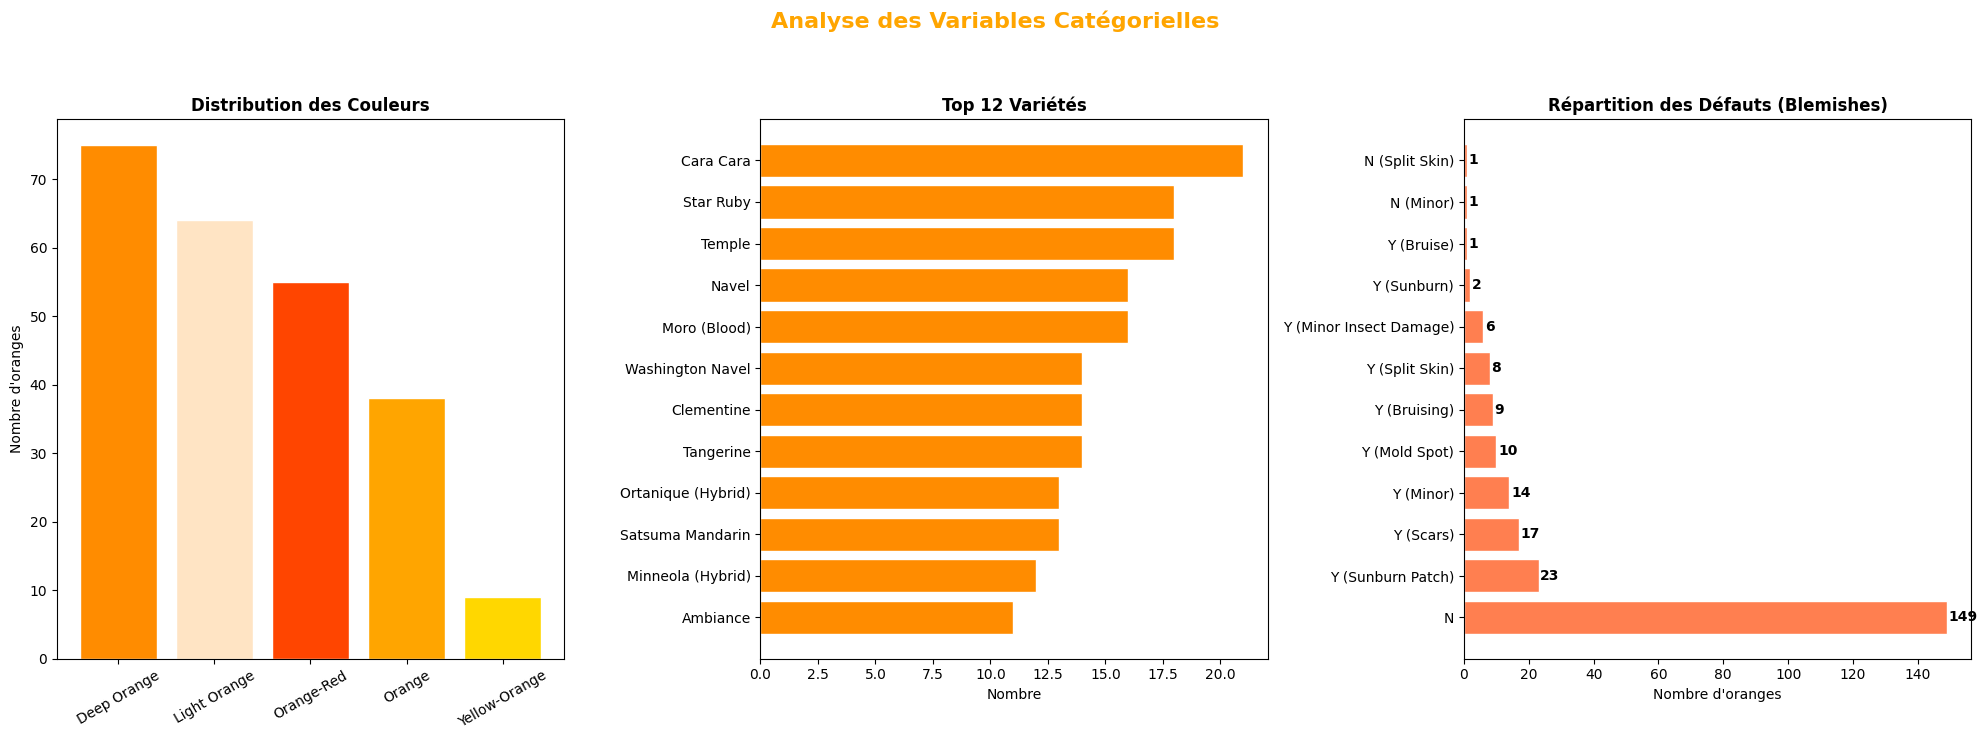

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 7)) # Un peu plus large pour l'espace
fig.suptitle('Analyse des Variables Catégorielles', fontsize=16, fontweight='bold', color='orange', y=1.05)

# Distribution des Couleurs
color_counts = dataOrange['Color'].value_counts()
valid_colors = ['darkorange', 'bisque', 'orangered', 'orange', 'gold'] 
axes[0].bar(color_counts.index, color_counts.values, color=valid_colors[:len(color_counts)], edgecolor='white')
axes[0].set_title('Distribution des Couleurs', fontweight='bold')
axes[0].set_ylabel('Nombre d\'oranges')
axes[0].tick_params(axis='x', rotation=30)

# Top 12 Variétés (Barres horizontales)
variety_counts = dataOrange['Variety'].value_counts().head(12)
axes[1].barh(variety_counts.index, variety_counts.values, color='darkorange', edgecolor='white')
axes[1].set_title('Top 12 Variétés', fontweight='bold')
axes[1].set_xlabel('Nombre')
axes[1].invert_yaxis()

# Barres horizontales pour les Défauts
blem = dataOrange['Blemishes(Y/N)'].value_counts()
# On utilise une couleur différente pour bien distinguer les défauts
axes[2].barh(blem.index, blem.values, color='coral', edgecolor='white')
axes[2].set_title('Répartition des Défauts (Blemishes)', fontweight='bold')
axes[2].set_xlabel('Nombre d\'oranges')

# Ajout des valeurs au bout des barres pour la précision
for i, v in enumerate(blem.values):
    axes[2].text(v + 0.5, i, str(v), color='black', fontweight='bold', va='center')

plt.tight_layout()
plt.show()

In [52]:
dataOrange["Blemishes(Y/N)"].value_counts().head()

Blemishes(Y/N)
N                    149
Y (Sunburn Patch)     23
Y (Scars)             17
Y (Minor)             14
Y (Mold Spot)         10
Name: count, dtype: int64

# Interpretation des Variables Catégorielles

Les oranges de cet échantillon présentent un profil globalement très sain. Côté couleur, les teintes foncées (Deep Orange, Light Orange, Orange-Red) dominent largement, signe d'une bonne maturité générale, tandis que le Yellow-Orange est la caractéristique des fruits jeunes reste anecdotique.
La diversité variétale est notable : 12 variétés sont représentées avec des effectifs assez équilibrés, la Cara Cara prenant légèrement la tête devant la Star Ruby et la Temple. Aucune variété n'écrase les autres, ce qui donne à cet échantillon une bonne représentativité.

Enfin, les défauts sont l'exception plutôt que la règle : 149 fruits sont parfaitement sains, et quand un défaut apparaît, il est le plus souvent superficiel d'un coup de soleil, cicatrice sans impact réel sur la qualité du fruit.

## 6- Analyse bivariee : 

## 6.1 - Variables numeriques

#
 Matrice de correlation

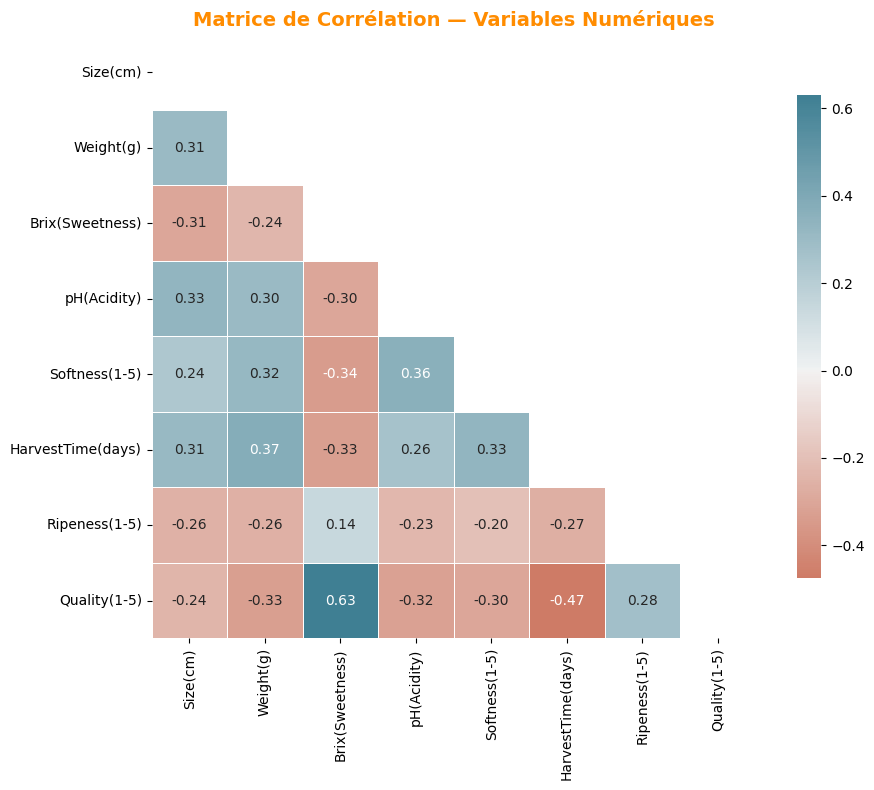


Corrélations avec la Qualité (triées) :
Brix(Sweetness)      0.631
Ripeness(1-5)        0.281
Size(cm)            -0.243
Softness(1-5)       -0.303
pH(Acidity)         -0.322
Weight(g)           -0.330
HarvestTime(days)   -0.475


In [18]:
num_data = dataOrange[num_cols].copy()
corr = num_data.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
cmap = sns.diverging_palette(20, 220, as_cmap=True)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap=cmap,
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={"shrink": 0.8})
ax.set_title('Matrice de Corrélation — Variables Numériques', fontsize=14, fontweight='bold', color='darkorange')
plt.tight_layout()
plt.show()

print("\nCorrélations avec la Qualité (triées) :")
print(corr['Quality(1-5)'].drop('Quality(1-5)').sort_values(ascending=False).round(3).to_string())


#
Interpretation :
* Brix(sucre) et Qualité (0.63) est lien le plus fort de la matrice : une orange sucrée est presque systématiquement bien notée.
* HarvestTime et Qualité (-0.47): plus une orange reste longtemps après récolte, plus sa qualité se dégrade. Le temps est l'ennemi de la fraîcheur.
* Softness et Qualité (-0.32): un fruit qui ramollit perd en qualité, mais l'effet est plus modéré que le temps de stockage.

## 6.2-  variables categorielles

#
test du Khi-2

In [17]:
from scipy.stats import chi2_contingency
import itertools

cat_cols = ['Color', 'Variety', 'Blemishes(Y/N)'] 

print("TEST DU KHI-2 — Variables Catégorielles")

for var1, var2 in itertools.combinations(cat_cols, 2):
    ct = pd.crosstab(dataOrange[var1], dataOrange[var2])
    chi2, p, dof, expected = chi2_contingency(ct)
    
    sig = "Relation significative" if p < 0.05 else " Pas de relation significative"
    force = (
        "forte" if chi2 > 50 else
        "modérée" if chi2 > 20 else
        "faible"
    )
    
    print(f"\n{var1} et {var2}")
    print(f"  Chi2     : {chi2:.3f}")
    print(f"  p-value  : {p:.4f}")
    print(f"  Degrés de liberté : {dof}")
    print(f"  => {sig} ({force})")

print("Seuil de significativité : p < 0.05")

TEST DU KHI-2 — Variables Catégorielles

Color et Variety
  Chi2     : 233.844
  p-value  : 0.0000
  Degrés de liberté : 92
  => Relation significative (forte)

Color et Blemishes(Y/N)
  Chi2     : 55.374
  p-value  : 0.1168
  Degrés de liberté : 44
  =>  Pas de relation significative (forte)

Variety et Blemishes(Y/N)
  Chi2     : 285.231
  p-value  : 0.0799
  Degrés de liberté : 253
  =>  Pas de relation significative (forte)
Seuil de significativité : p < 0.05


#
 Interprétation du Khi-2

**Color et Variety (Chi2=233.8, p≈0.000)** : Relation significative et forte. La couleur d'une orange n'est pas un hasard, elle est bien liée à sa variété. Certaines variétés produisent systématiquement des couleurs particulières, ce qui est biologiquement logique.

**Color et Blemishes (Chi2=55.4, p=0.117)** : Pas de relation significative. La couleur d'une orange ne permet pas de prédire si elle aura des défauts ou non. Un fruit rouge-orangé n'est pas plus ou moins abîmé qu'un fruit jaune-orangé.

**Variety et Blemishes (Chi2=285.2, p=0.080)**: Pas de relation significative, mais la p-value frôle le seuil (0.08 vs 0.05). C'est une zone grise, on ne peut pas conclure formellement, mais ce n'est pas non plus une indépendance totale. Certaines variétés pourraient être légèrement plus sujettes aux défauts, mais l'échantillon n'est pas assez grand pour le confirmer.

# 6.3- variables numeriques et variables categorielles

#
ANOVA

In [20]:
from scipy.stats import f_oneway, ttest_ind
import itertools

num_cols = ['Size(cm)', 'Weight(g)', 'Brix(Sweetness)', 'pH(Acidity)', 
            'Softness(1-5)', 'HarvestTime(days)', 'Ripeness(1-5)', 'Quality(1-5)']

cat_cols = ['Color', 'Variety', 'Blemishes(Y/N)']
print("RELATION VARIABLES NUMÉRIQUES ↔ CATÉGORIELLES")

for cat in cat_cols:
    modalites = dataOrange[cat].nunique()
    test_name = "T-test" if modalites == 2 else "ANOVA"
    
    print(f"\n{cat} ({modalites} modalités) et {test_name}")
    
    for num in num_cols:
        groupes = [dataOrange[dataOrange[cat] == mod][num].dropna() for mod in dataOrange[cat].unique()]
        
        if modalites == 2:
            stat, p = ttest_ind(*groupes)
        else:
            stat, p = f_oneway(*groupes)
        
        sig = " significative" if p < 0.05 else "non significative"
        print(f"  {sig} {num:<25} stat={stat:.3f}  p={p:.4f}")


print("Seuil : p < 0.05")

RELATION VARIABLES NUMÉRIQUES ↔ CATÉGORIELLES

Color (5 modalités) et ANOVA
   significative Size(cm)                  stat=4.894  p=0.0008
   significative Weight(g)                 stat=3.751  p=0.0056
   significative Brix(Sweetness)           stat=19.110  p=0.0000
   significative pH(Acidity)               stat=5.460  p=0.0003
   significative Softness(1-5)             stat=10.387  p=0.0000
   significative HarvestTime(days)         stat=7.963  p=0.0000
   significative Ripeness(1-5)             stat=2.570  p=0.0387
   significative Quality(1-5)              stat=10.801  p=0.0000

Variety (24 modalités) et ANOVA
   significative Size(cm)                  stat=2.696  p=0.0001
  non significative Weight(g)                 stat=1.419  p=0.1034
   significative Brix(Sweetness)           stat=2.076  p=0.0038
   significative pH(Acidity)               stat=3.314  p=0.0000
   significative Softness(1-5)             stat=2.170  p=0.0022
   significative HarvestTime(days)         stat=2.755

#
Interpretation:
 Interprétation ANOVA: Numériques et Catégorielles

**Color et Variables numériques**: C'est la relation la plus forte : toutes les variables numériques sont significativement liées à la couleur sans exception. La couleur d'une orange n'est pas qu'esthétique, elle reflète fidèlement son profil complet : taille, poids, sucre, acidité, texture, temps de récolte et qualité. La couleur est quasiment un résumé visuel de l'orange.

**Variety et Variables numériques** : La variété influence significativement la plupart des variables,sauf le poids et la maturité (Ripeness). Autrement dit, selon la variété, les oranges diffèrent en taille, sucre, acidité, texture et qualité,mais leur poids et leur niveau de maturité restent comparables d'une variété à l'autre.

**Blemishes et Variables numériques** : C'est la relation la plus faible des trois. Les défauts ne sont liés significativement qu'à quelques variables isolées (poids, maturité notamment), et pas du tout à la qualité finale (p=0.117). Cela confirme ce qu'on avait observé avec le Khi-2 : les défauts sont superficiels et n'impactent pas vraiment la qualité intrinsèque du fruit.

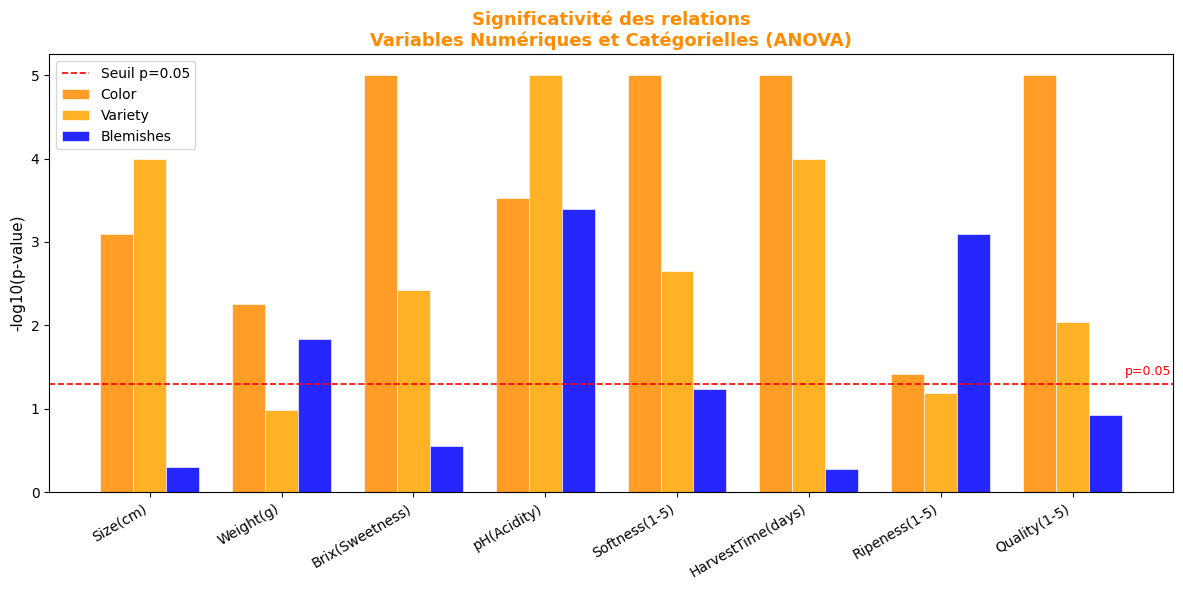

In [22]:
variables = ['Size(cm)', 'Weight(g)', 'Brix(Sweetness)', 'pH(Acidity)', 
             'Softness(1-5)', 'HarvestTime(days)', 'Ripeness(1-5)', 'Quality(1-5)']

results = {
    'Color':     [0.0008, 0.0056, 0.0000, 0.0003, 0.0000, 0.0000, 0.0387, 0.0000],
    'Variety':   [0.0001, 0.1034, 0.0038, 0.0000, 0.0022, 0.0001, 0.0646, 0.0090],
    'Blemishes': [0.4942, 0.0144, 0.2765, 0.0004, 0.0582, 0.5205, 0.0008, 0.1173]
}

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(variables))
width = 0.25
colors_bar = ['darkorange', 'orange', 'blue']

for i, (cat, pvals) in enumerate(results.items()):
    hauteurs = [-np.log10(p) if p > 0 else 5 for p in pvals]
    bars = ax.bar(x + i * width, hauteurs, width=width,
                  color=colors_bar[i], alpha=0.85, label=cat,
                  edgecolor='white', linewidth=0.5)

# Seuil p=0.05
seuil = -np.log10(0.05)
ax.axhline(y=seuil, color='red', linestyle='--', linewidth=1.2, label='Seuil p=0.05')
ax.text(7.65, seuil + 0.1, 'p=0.05', color='red', fontsize=9)

ax.set_xticks(x + width)
ax.set_xticklabels(variables, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('-log10(p-value)', fontsize=11)
ax.set_title('Significativité des relations\nVariables Numériques et Catégorielles (ANOVA)',
             fontsize=13, fontweight='bold', color='darkorange')
ax.legend(fontsize=10)
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

plt.tight_layout()
plt.show()

#
Interprétation du graphique

La ligne rouge pointillée est le seuil : toute barre qui la dépasse = relation significative.

**Color (orange foncé) le plus puissant** : Toutes les barres dépassent largement le seuil. La couleur est liée à absolument toutes les variables numériques, avec une force particulièrement élevée sur le Brix, la Softness, HarvestTime et la Quality. C'est la variable catégorielle la plus informative du dataset.

**Variety (orange clair) très proche de Color** : Quasiment toutes les barres dépassent le seuil, sauf Weight et Ripeness qui restent en dessous. La variété explique bien les différences entre fruits, mais ne détermine ni leur poids ni leur maturité.

**Blemishes (bleu) le plus faible** : C'est visuellement frappant : la majorité des barres bleues restent sous la ligne rouge. Seuls pH et Ripeness dépassent le seuil. Les défauts sont donc largement indépendants des caractéristiques physiques et chimiques des oranges.